In [1]:
import time as time
import numpy as np 
import psutil as psutil
import inspect as inspect
import os as os
from scipy.stats import norm
from scipy.optimize import bisect
import matplotlib.pyplot as plt

In [ ]:
def ou_stats(x0, kappa, sigma, t, T):
    mean = x0 * np.exp(-kappa * (T - t))
    var = (sigma**2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * (T-t)))
    return mean, var

def ou_call_price(K, T, kappa, sigma, x0=0, mu=0):
    """
    Docstring for ou_call_price
    
    :param K: Description
    :param T: Description
    :param kappa: Description
    :param sigma: Description
    :param x0: Description
    :param mu: Description
    """
    mean_T = x0 * np.exp(-kappa * T) + mu * (1-np.exp(-kappa * T))

    variance_T = (sigma**2 / (2 * kappa)) * (1- np.exp(-2 * kappa * T))
    std_T = np.sqrt(variance_T)

    d = (mean_T - K) / std_T

    # Final Price Formula
    price = (mean_T - K) * norm.cdf(d) + std_T * norm.pdf(d)

    return price

def gen_sigmoid_weights(strikes):
    """
    Generates weights w_j such that sum of calls approximates sigmoid/
    
    :param strikes: Grid of NxN containing the strikes of the call options
    """
    varsigma = lambda x: 1.0/ (1.0 + np.exp(-x))
    vals = varsigma(strikes)
    w = np.zeros(len(strikes))
    # weights for linear interpolation on the grid

    w[0] = (vals[1] - vals[0]) / (strikes[1] - strikes[0])
    for j in range(1, len(strikes) - 1):
        # fd approximates the second derivative of the sigmoid at point Kj
        w[j] = (vals[j+1] - vals[j])/(strikes[j+1] - strikes[j]) - \
                (vals[j] - vals[j-1])/(strikes[j] - strikes[j-1])
    return w

def ppa_payoff(path_history):
    """
    path_history: tensor/array van vorm (nSamples, nSteps + 1, nFeatures)
    Feature 0: Forward Price f(t,T)
    Feature 1: Onshore Infeed realization/forecast
    """
    f_T_T = path_history[:, -1, 0] # De spotprijs op T
    q_T = path_history[:, -1, 1]   # De werkelijke infeed op T
    
    strike = 100.0
    capacity = 1.0
    
    # Payoff voor de offtaker (buyer of the PPA)
    payoff = capacity * q_T * (f_T_T - strike)
    
    return payoff

def get_expected_q(x_t, T_rem, kappa, sigma, phi):
    """
    Berekent E[sigmoid(X_T + phi) | F_t] 
    door de sigmoid te benaderen als gewogen som van call opties.
    """
    if T_rem <= 0:
        # Op de einddatum is de verwachting gewoon de realisatie
        return 1.0 / (1.0 + np.exp(-(x_t + phi)))
    
    res = np.zeros_like(x_t)
    for j in range(len(strikes)):
        # Gebruik de analytische prijs van een call op een OU proces
        res += weights[j] * ou_call_price(K=strikes[j] - phi, 
                                          T=T_rem, 
                                          kappa=kappa, 
                                          sigma=sigma, 
                                          x0=x_t)
    return res

def calibrate_phi(target_forecast, kappa, sigma, T_max):
    """
    Zoekt de waarde van phi waarvoor de verwachting op t=0 
    gelijk is aan de marktvoorspelling (bijv. 0.5).
    """
    def objective(phi_guess):
        # Op t=0 is x0 = 0
        val = get_expected_q(np.array([0.0]), T_max, kappa, sigma, phi_guess)
        return val[0] - target_forecast
    
    # Gebruik bisection om de nulpuntswaarde te vinden
    return bisect(objective, -5, 5)
def varsigma(x):
    
    return 1.0 / (1.0 + np.exp(-x)) 

strikes = np.linspace(-5, 5, 20)
weights = gen_sigmoid_weights(strikes)

In [3]:
nSamples = 100000
nSteps = 48
T_max = 48
dt = T_max / nSteps

#OU parameters
kappa_q1 = kappa_q2 = 0.1 / 24.0 # Kappa is dagelijks, dus schalen met T door te delen met uren per dag
sigma_q1 = sigma_q2 = 3.0 / np.sqrt(365.0 * 24.0) # Sigma is annualized, dus delen door 365 * 24

kappa_p_daily = 0.5
sigma_p_daily = 0.8

kappa_p = kappa_p_daily / 24.0
sigma_p = sigma_p_daily / np.sqrt(365 * 24.0)
rho = 0.46 # Correlation between onshore and offshore

# forward info op t=0
f_0_T = 100.0
q1_target = 0.5
q2_target = 0.6
w1 = 0.91
w2 = 0.09

update_times = [0, 10, 14, 18, 34, 38, 42]

# Kalibreer phi's (gebruik de functies die we eerder hebben gedefinieerd)
phi_q1 = calibrate_phi(q1_target, kappa_q1, sigma_q1, T_max)
phi_q2 = calibrate_phi(q2_target, kappa_q2, sigma_q2, T_max)

# Fix voor de startwaarde op 100 (g0 kalibratie)
E_q1_0 = get_expected_q(np.array([0.0]), T_max, kappa_q1, sigma_q1, phi_q1)[0]
E_q2_0 = get_expected_q(np.array([0.0]), T_max, kappa_q2, sigma_q2, phi_q2)[0]
g0 = 1.0 - (w1 * E_q1_0 + w2 * E_q2_0)

# Idiosyncratische startwaarde (M0)
m0_mean, m0_var = ou_stats(0.0, kappa_p, sigma_p, 0, T_max)
#idio0 = np.exp(m0_mean + 0.5 * m0_var)
idio0 = 1.0 + m0_mean

# Simulatie initialisatie
x1 = np.zeros((nSamples, nSteps + 1))
x2 = np.zeros((nSamples, nSteps + 1))
xp = np.zeros((nSamples, nSteps + 1))
f_t_T = np.zeros((nSamples, nSteps + 1))
q1_t_T = np.zeros((nSamples, nSteps + 1))
q2_t_T = np.zeros((nSamples, nSteps + 1 ))


for t in range(nSteps + 1):
    t_curr = t * dt
    
    if t_curr in update_times:
        t_minus_idx = t 
    
    T_rem_minus = T_max - (t_minus_idx * dt)

    if t > 0:
        z1 = np.random.normal(size=nSamples)
        z_raw = np.random.normal(size=nSamples)
        z2 = rho * z1 + np.sqrt(1 - rho**2) * z_raw
        zp = np.random.normal(size=nSamples)

        # evo of OU processes
        x1[:, t] = x1[:, t-1] * np.exp(-kappa_q1 * dt) + \
                   sigma_q1 * np.sqrt((1 - np.exp(-2 * kappa_q1 * dt)) / (2 * kappa_q1)) * z1
        x2[:, t] = x2[:, t-1] * np.exp(-kappa_q2 * dt) + \
                   sigma_q2 * np.sqrt((1 - np.exp(-2 * kappa_q2 * dt)) / (2 * kappa_q2)) * z2
        xp[:, t] = xp[:, t-1] * np.exp(-kappa_p * dt) + \
                   sigma_p * np.sqrt((1 - np.exp(-2 * kappa_p * dt)) / (2 * kappa_p)) * zp

    
    # infeed forecasts
    
    eq1_m = get_expected_q(x1[:, t_minus_idx], T_rem_minus, kappa_q1, sigma_q1, phi_q1)
    eq2_m = get_expected_q(x2[:, t_minus_idx], T_rem_minus, kappa_q2, sigma_q2, phi_q2)
    
    # for plot
    q1_t_T[:, t] = eq1_m 
    q2_t_T[:, t] = eq2_m

   # forward price
    
    gt = 1.0 - (w1 * eq1_m + w2 * eq2_m)
    
    # idiosyncratic component
    mt_mean, mt_var = ou_stats(xp[:, t], kappa_p, sigma_p, t_curr, T_max)
    #idiot = np.exp(mt_mean + 0.5 * mt_var)
    idiot = 1.0 + mt_mean
    
    
    f_t_T[:, t] = f_0_T * (idiot / idio0) * (gt / g0)


In [6]:
print(f"Wind evolution OU: {x1[5]}")
print(f"wind onshore infeed forecast: {eq1_m}")

Wind evolution OU: [ 0.          0.0032176  -0.01938476 -0.04340601 -0.08472883 -0.07292817
 -0.0723742  -0.10138622 -0.10311151 -0.15316892 -0.16728928 -0.15612036
 -0.12780523 -0.16230994 -0.13137818 -0.1102597  -0.10209082 -0.08354561
 -0.05991973 -0.04209785 -0.05924959 -0.11095845 -0.12757938 -0.123316
 -0.13775884 -0.08942949 -0.09508789 -0.15498044 -0.19030069 -0.20085003
 -0.15604987 -0.12140471 -0.12551769 -0.12665845 -0.15646763 -0.12964182
 -0.09915445 -0.09319898 -0.13698679 -0.09620352 -0.09603967 -0.14597192
 -0.12232171 -0.13880625 -0.11618488 -0.14724723 -0.14878631 -0.09721486
 -0.13778795]
wind onshore infeed forecast: [0.5741412  0.52048754 0.48658251 ... 0.56265882 0.58038207 0.44239923]


In [12]:
# In your figure replication code (the one that works)
print(f"Figure code - Spot price f(T,T) at maturity:")
print(f"  Mean: {np.mean(f_t_T[:, -1]):.4f}")
print(f"  Variance: {np.var(f_t_T[:, -1]):.4f}")

Figure code - Spot price f(T,T) at maturity:
  Mean: 99.9992
  Variance: 93.1840


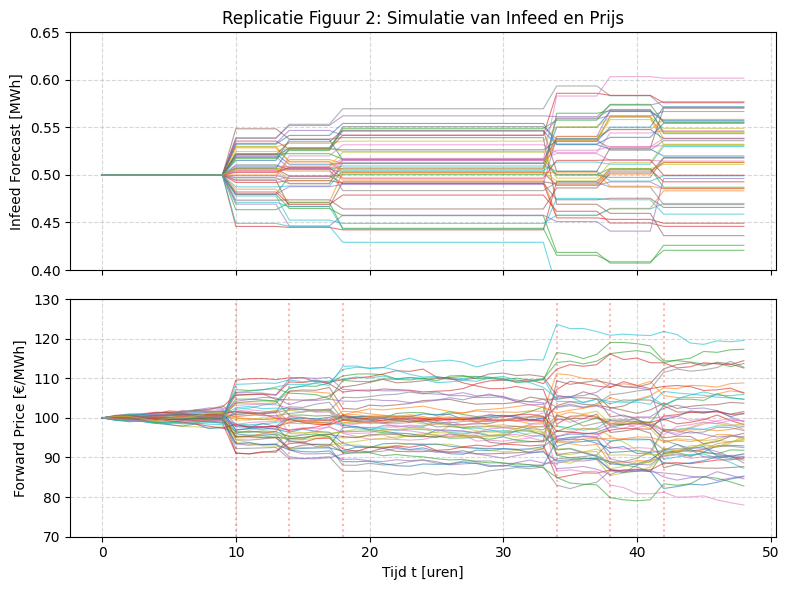

In [8]:
# Maak de figuren en subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

# Tijd-as (in uren of stappen)
t_axis = np.linspace(0, T_max, nSteps + 1)

# 1. Bovenste plot: Infeed Forecast Q1(t, T)
for i in range(min(nSamples, 50)): # Plot de eerste 50 paden voor overzichtelijkheid
    ax1.plot(t_axis, q1_t_T[i, :], lw=0.8, alpha=0.6)

ax1.set_ylabel('Infeed Forecast [MWh]')
ax1.set_title('Replicatie Figuur 2: Simulatie van Infeed en Prijs')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylim(0.4, 0.65)

# 2. Onderste plot: Forward Price f(t, T)
for i in range(min(nSamples, 50)):
    ax2.plot(t_axis, f_t_T[i, :], lw=0.8, alpha=0.6)

ax2.set_ylabel('Forward Price [€/MWh]')
ax2.set_xlabel('Tijd t [uren]')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(70,130)

# Optioneel: Markeer de update-tijdstippen met verticale lijnen
update_times = [10, 14, 18, 34, 38, 42]
for ut in update_times:
    ax2.axvline(x=ut, color='red', linestyle=':', alpha=0.3, label='Weather Update' if ut==10 else "")

plt.savefig("stoch_model.jpg", dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
#print(f_t_T[:1000])
print(f_t_T[:2,])
print(q1_t_T[:2,])
print(q2_t_T[:2,])

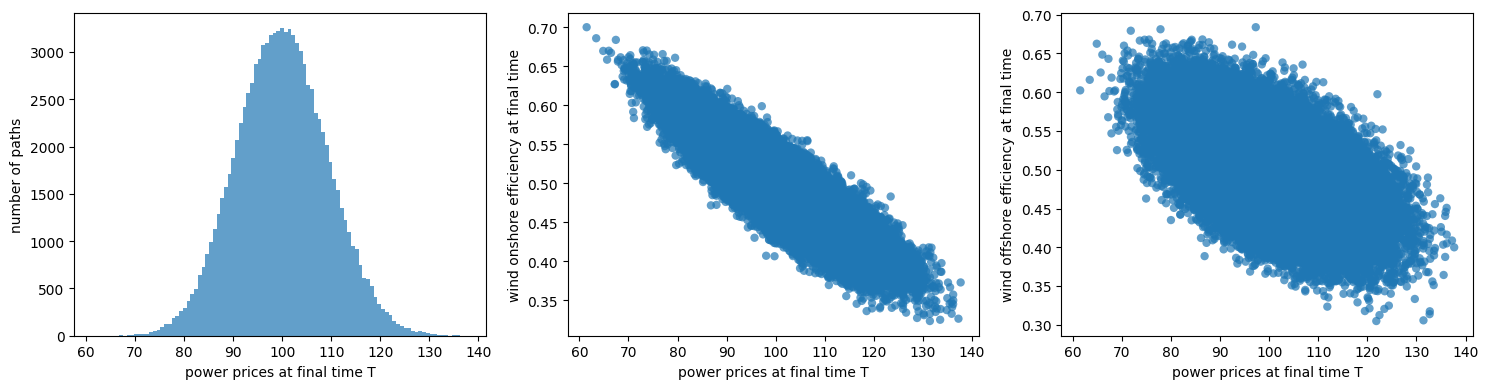

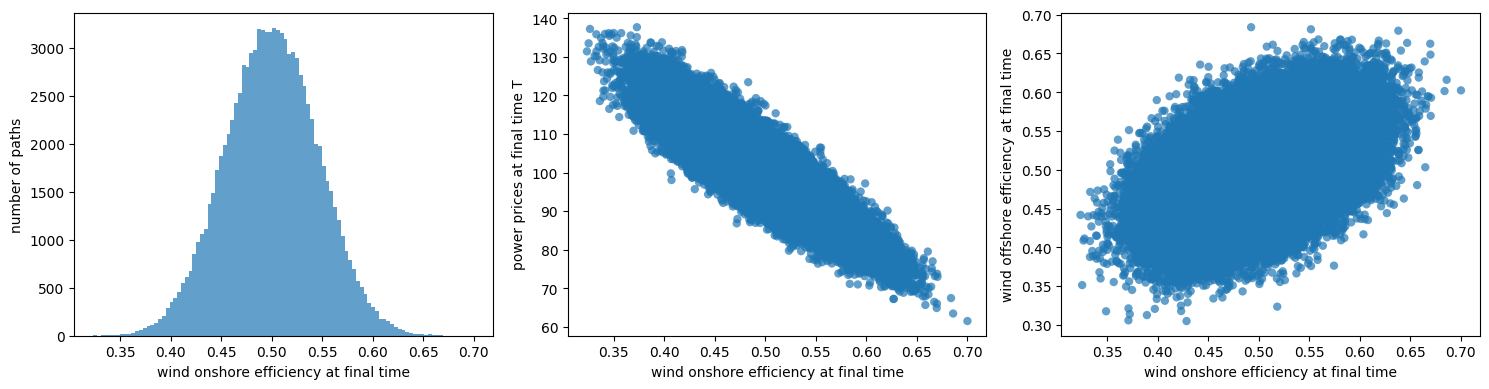

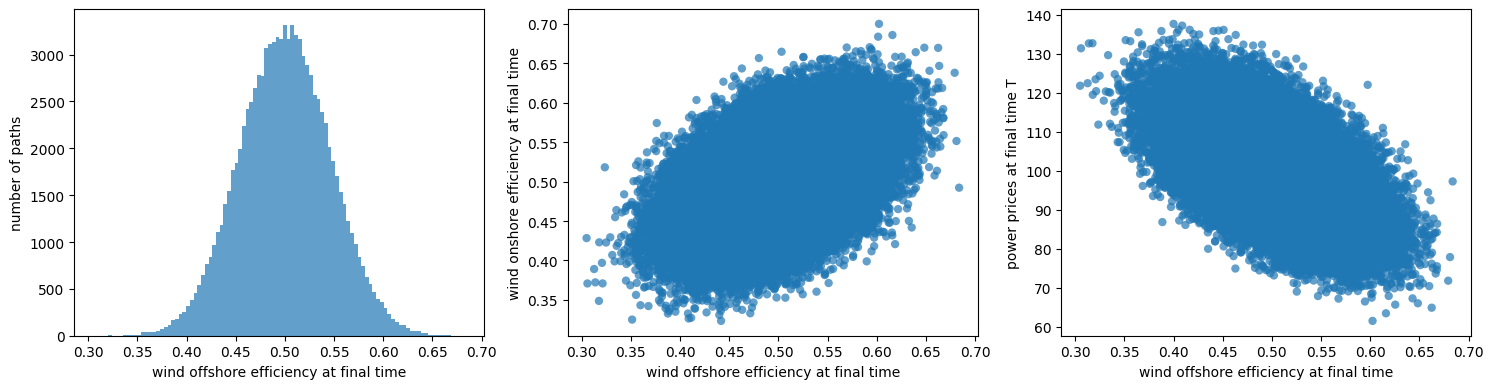

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

final_prices = f_t_T[:, -1]
final_infeed_onshore = q1_t_T[:, -1]
final_infeed_offshore = q2_t_T[:, -1]

vars_to_plot = [final_prices, final_infeed_onshore, final_infeed_offshore]
titles = ["power prices at final time T", "wind onshore efficiency at final time", "wind offshore efficiency at final time"]
for idx, var in enumerate(vars_to_plot):
    fig, ax = plt.subplots(1,3, sharex=True, figsize=(15,4))

    ax[0].hist(var, bins=100, color='tab:blue', edgecolor='none', alpha=0.7)
    ax[0].set_xlabel(titles[idx])
    ax[0].set_ylabel("number of paths")
    
    if np.array_equal(var, final_infeed_onshore):
        ax[1].scatter(var, final_prices, color='tab:blue', edgecolor='none', alpha=0.7)
        ax[1].set_ylabel(titles[0])
    else:
        ax[1].scatter(var, final_infeed_onshore, color='tab:blue', edgecolor='none', alpha=0.7)
        ax[1].set_ylabel(titles[1])
    ax[1].set_xlabel(titles[idx])
    
    if np.array_equal(var, final_infeed_offshore):
        ax[2].scatter(var, final_prices, color='tab:blue', edgecolor='none', alpha=0.7)
        ax[2].set_ylabel(titles[0])
    else: 
        ax[2].scatter(var, final_infeed_offshore, color='tab:blue', edgecolor='none', alpha=0.7)
        ax[2].set_ylabel(titles[2])
    ax[2].set_xlabel(titles[idx])

    plt.tight_layout()
    plt.show()


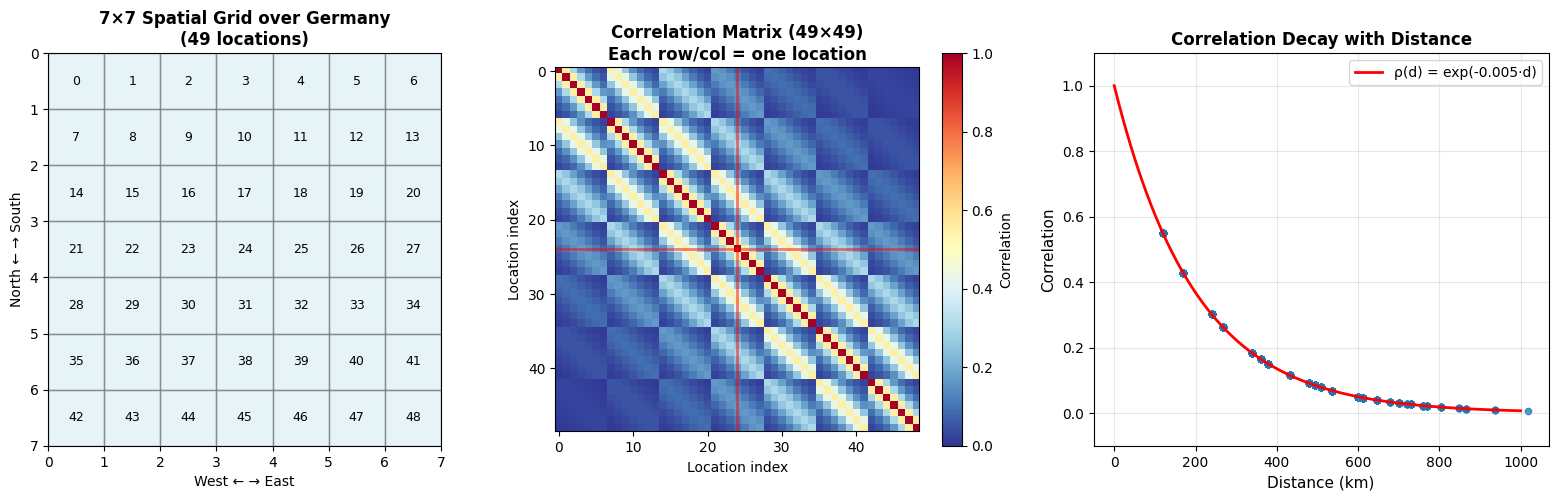

Interpretation:
• Left: 49 grid cells covering Germany (7×7)
• Middle: Correlation between all pairs of locations
  - Diagonal = 1 (location correlates perfectly with itself)
  - Red lines = correlations for center location (24)
  - Nearby locations have high correlation (red)
  - Distant locations have low correlation (blue)
• Right: Correlation decays exponentially with distance
  - Locations 120 km apart: ρ ≈ 0.55
  - Locations 500 km apart: ρ ≈ 0.08


In [7]:
# Visualization of Multivariate OU with Spatial Grid
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# === 1. THE SPATIAL GRID ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Physical grid over Germany
ax = axes[0]
gridsize = 7

# Draw grid
for i in range(gridsize):
    for j in range(gridsize):
        rect = Rectangle((j, i), 1, 1, linewidth=1, 
                         edgecolor='black', facecolor='lightblue', alpha=0.3)
        ax.add_patch(rect)
        # Add location index
        location_idx = i * gridsize + j
        ax.text(j + 0.5, i + 0.5, f'{location_idx}', 
                ha='center', va='center', fontsize=9)

ax.set_xlim(0, gridsize)
ax.set_ylim(0, gridsize)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_title('7×7 Spatial Grid over Germany\n(49 locations)', fontsize=12, fontweight='bold')
ax.set_xlabel('West ← → East')
ax.set_ylabel('North ← → South')
ax.grid(True, alpha=0.3)

# === 2. CORRELATION MATRIX ===
ax = axes[1]

# Build correlation matrix with exponential decay
def construct_correlation_matrix(gridsize=7, alpha=0.005):
    n = gridsize * gridsize
    Corr = np.eye(n)
    
    for i in range(n):
        for j in range(n):
            i_row, i_col = i // gridsize, i % gridsize
            j_row, j_col = j // gridsize, j % gridsize
            
            # Distance in grid units (multiply by ~120 km for Germany)
            dist = np.sqrt((i_row - j_row)**2 + (i_col - j_col)**2)
            dist_km = dist * 120
            
            Corr[i, j] = np.exp(-alpha * dist_km)
    
    return Corr

Corr = construct_correlation_matrix(gridsize=7, alpha=0.005)

im = ax.imshow(Corr, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_title('Correlation Matrix (49×49)\nEach row/col = one location', fontsize=12, fontweight='bold')
ax.set_xlabel('Location index')
ax.set_ylabel('Location index')
plt.colorbar(im, ax=ax, label='Correlation')

# Highlight one location's correlations
ax.axhline(y=24, color='red', linewidth=2, alpha=0.5)  # Center location
ax.axvline(x=24, color='red', linewidth=2, alpha=0.5)

# === 3. CORRELATION vs DISTANCE ===
ax = axes[2]

# Extract correlations vs distances
distances_km = []
correlations = []

for i in range(49):
    for j in range(i+1, 49):
        i_row, i_col = i // 7, i % 7
        j_row, j_col = j // 7, j % 7
        
        dist = np.sqrt((i_row - j_row)**2 + (i_col - j_col)**2)
        dist_km = dist * 120
        
        distances_km.append(dist_km)
        correlations.append(Corr[i, j])

ax.scatter(distances_km, correlations, alpha=0.5, s=20)
ax.plot(np.linspace(0, 1000, 100), 
        np.exp(-0.005 * np.linspace(0, 1000, 100)), 
        'r-', linewidth=2, label='ρ(d) = exp(-0.005·d)')
ax.set_xlabel('Distance (km)', fontsize=11)
ax.set_ylabel('Correlation', fontsize=11)
ax.set_title('Correlation Decay with Distance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('spatial_grid_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print("• Left: 49 grid cells covering Germany (7×7)")
print("• Middle: Correlation between all pairs of locations")
print("  - Diagonal = 1 (location correlates perfectly with itself)")
print("  - Red lines = correlations for center location (24)")
print("  - Nearby locations have high correlation (red)")
print("  - Distant locations have low correlation (blue)")
print("• Right: Correlation decays exponentially with distance")
print(f"  - Locations 120 km apart: ρ ≈ {np.exp(-0.005*120):.2f}")
print(f"  - Locations 500 km apart: ρ ≈ {np.exp(-0.005*500):.2f}")

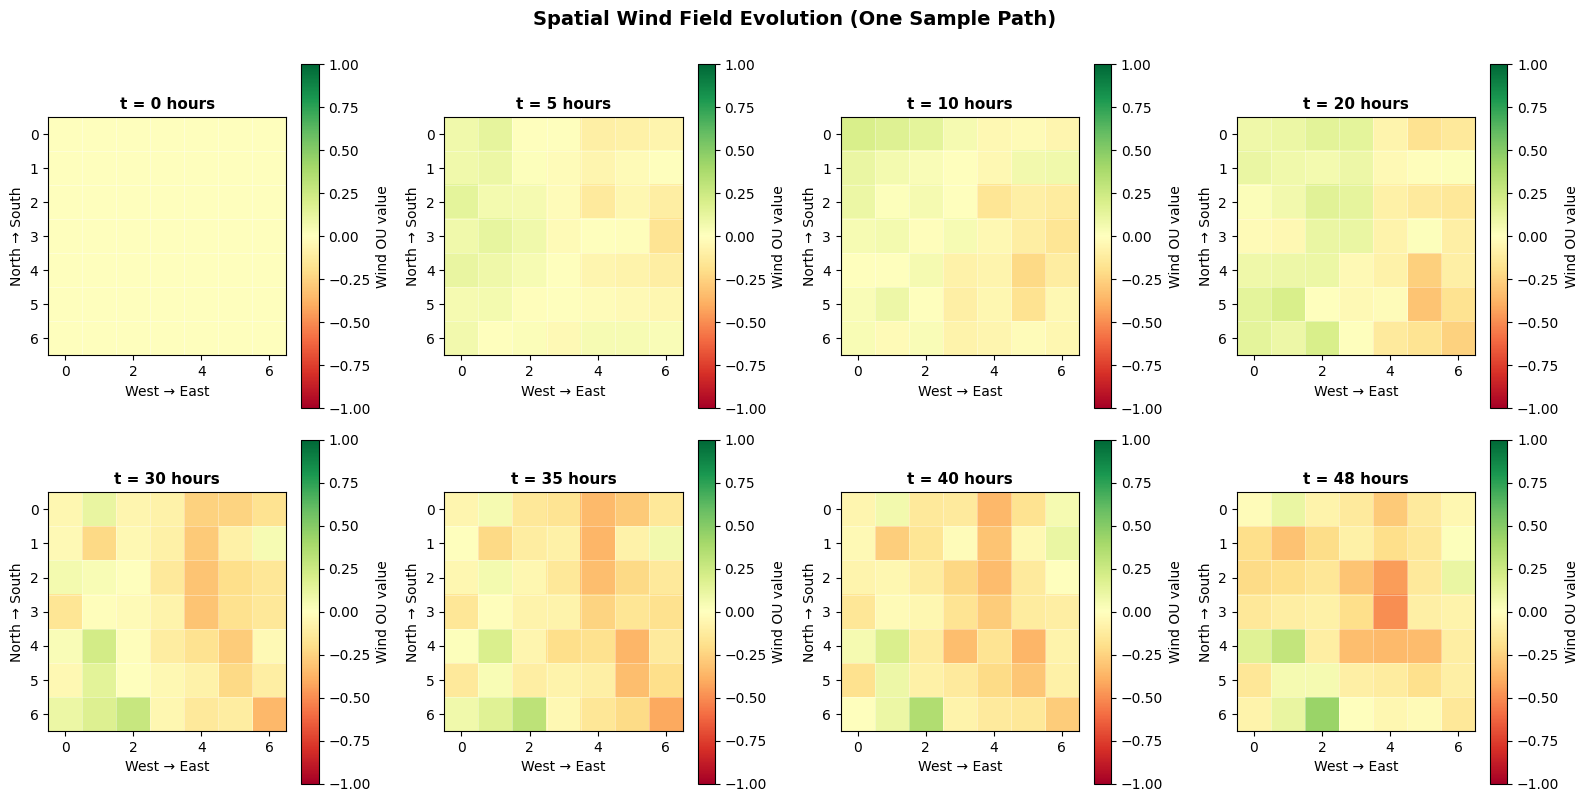


What you're seeing:
• Each panel = wind field at different time
• Each cell = one OU process value at one location
• Notice: nearby cells have similar colors (spatial correlation!)
• Green = positive wind anomaly, Red = negative anomaly


In [17]:
# === SIMULATE ONE SAMPLE PATH OF SPATIAL WIND FIELD ===

#np.random.seed(42)
gridsize = 7
nSteps = 48
dt = 1.0  # hourly

# OU parameters (same as your current code)
kappa_q1 = 0.1 / 24.0
sigma_q1 = 3.0 / np.sqrt(365.0 * 24.0)

# Build correlation matrix and Cholesky decomposition
Corr = construct_correlation_matrix(gridsize=7, alpha=0.005)
L = np.linalg.cholesky(Corr)

# Initialize wind field for ONE sample path
x1_spatial = np.zeros((nSteps + 1, gridsize, gridsize))

# Simulate over time
for t in range(1, nSteps + 1):
    # Generate 49 correlated shocks
    z_uncorr = np.random.normal(size=49)
    z_corr = L @ z_uncorr  # Correlate them
    z_grid = z_corr.reshape(gridsize, gridsize)
    
    # Apply OU update to each location
    x1_spatial[t] = (x1_spatial[t-1] * np.exp(-kappa_q1 * dt) + 
                     sigma_q1 * np.sqrt((1 - np.exp(-2*kappa_q1*dt))/(2*kappa_q1)) * z_grid)

# === VISUALIZE EVOLUTION ===
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

timesteps_to_show = [0, 5, 10, 20, 30, 35, 40, 48]

for idx, t in enumerate(timesteps_to_show):
    ax = axes[idx // 4, idx % 4]
    
    # Plot the wind field at this timestep
    im = ax.imshow(x1_spatial[t], cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_title(f't = {t} hours', fontsize=11, fontweight='bold')
    ax.set_xlabel('West → East')
    ax.set_ylabel('North → South')
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Wind OU value')
    
    # Add grid
    for i in range(gridsize + 1):
        ax.axhline(i - 0.5, color='white', linewidth=0.5, alpha=0.5)
        ax.axvline(i - 0.5, color='white', linewidth=0.5, alpha=0.5)

plt.suptitle('Spatial Wind Field Evolution (One Sample Path)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('wind_field_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nWhat you're seeing:")
print("• Each panel = wind field at different time")
print("• Each cell = one OU process value at one location")
print("• Notice: nearby cells have similar colors (spatial correlation!)")
print("• Green = positive wind anomaly, Red = negative anomaly")